# COGNIFYZ TECHNOLOGIES - DATA SCIENCE INTERNSHIP PROJECT

### Project Name - Restaurant Data Analysis 
### Project Type - EDA
### Intern Name - Aditi Ganpat Khade 

# Level 1 Tasks :-

## ******************************* Import Libraries *******************************

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib
%matplotlib inline
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Ignore all warnings
import warnings
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## ******************************* Loading Dataset *******************************

In [3]:
# Load Dataset from github repository
df = pd.read_csv(r'C:\Users\Administrator\Desktop\Cognifyz Technologies\Project\Dataset .csv')

# ════════════════════════════════════════════════════
# LEVEL 1 │ TASK 1 – Data Exploration & Preprocessing
# ════════════════════════════════════════════════════

In [5]:
# View top 5 rows of the dataset
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## ******************************* Dataset Rows & Columns count *******************************

In [9]:
# Checking number of rows and columns of the dataset using shape
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])

Number of rows are:  9551
Number of columns are:  21


## ******************************* Duplicate Values *******************************

In [11]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')

number of duplicated rows are 0


## ******************************* Missing Values/Null Values *******************************

In [13]:
missing     = df.isnull().sum()
missing_pct = (missing / df.shape[0] * 100).round(2)

# DataFrame with all columns and missing info
summary_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Has Missing?': missing > 0
})

# Columns with missing values only
missing_df = summary_df[summary_df['Has Missing?']]

# Columns with no missing values
no_missing_df = summary_df[~summary_df['Has Missing?']]

print(f"\n🔍 Missing Values Found in {len(missing_df)} column(s):")
print(missing_df.to_string())

print(f"\n✅ Columns with No Missing Values ({len(no_missing_df)}):")
print(no_missing_df.to_string())


🔍 Missing Values Found in 1 column(s):
          Missing Count  Missing %  Has Missing?
Cuisines              9       0.09          True

✅ Columns with No Missing Values (20):
                      Missing Count  Missing %  Has Missing?
Restaurant ID                     0        0.0         False
Restaurant Name                   0        0.0         False
Country Code                      0        0.0         False
City                              0        0.0         False
Address                           0        0.0         False
Locality                          0        0.0         False
Locality Verbose                  0        0.0         False
Longitude                         0        0.0         False
Latitude                          0        0.0         False
Average Cost for two              0        0.0         False
Currency                          0        0.0         False
Has Table booking                 0        0.0         False
Has Online delivery          

## ******************************* Handle missing values *******************************

In [15]:
df['Cuisines'].fillna('Unknown', inplace=True)
print("\n✅ Missing 'Cuisines' values filled with 'Unknown'")
print(f"   Remaining missing values: {df.isnull().sum().sum()}")


✅ Missing 'Cuisines' values filled with 'Unknown'
   Remaining missing values: 0


## ******************************* Data type conversion *******************************

In [17]:
print(df[['Has Table booking','Has Online delivery','Is delivering now']].dtypes.to_string())

df['Has Table booking']   = df['Has Table booking'].map({'Yes':1,'No':0})
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes':1,'No':0})
df['Is delivering now']   = df['Is delivering now'].map({'Yes':1,'No':0})
print("\n✅ Converted Yes/No columns to binary (1/0)")

Has Table booking      object
Has Online delivery    object
Is delivering now      object

✅ Converted Yes/No columns to binary (1/0)


## ******************************* Visualizing *******************************

In [21]:
# count each rating value
rating_counts = df['Aggregate rating'].value_counts().sort_index()

# print counts
print(rating_counts.to_string())

# count zeros and non-zero ratings
zero_rated = (df['Aggregate rating'] == 0).sum()
rated = (df['Aggregate rating'] > 0).sum()

# print class imbalance
total = df.shape[0]
print(
    f"\n⚠ Class Imbalance: {zero_rated} restaurants have 0 rating "
    f"({zero_rated/total*100:.1f}%) vs {rated} with actual ratings "
    f"({rated/total*100:.1f}%)"
)

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61

⚠ Class Imbalance: 2148 restaurants have 0 rating (22.5%) vs 7403 with actual ratings (77.5%)


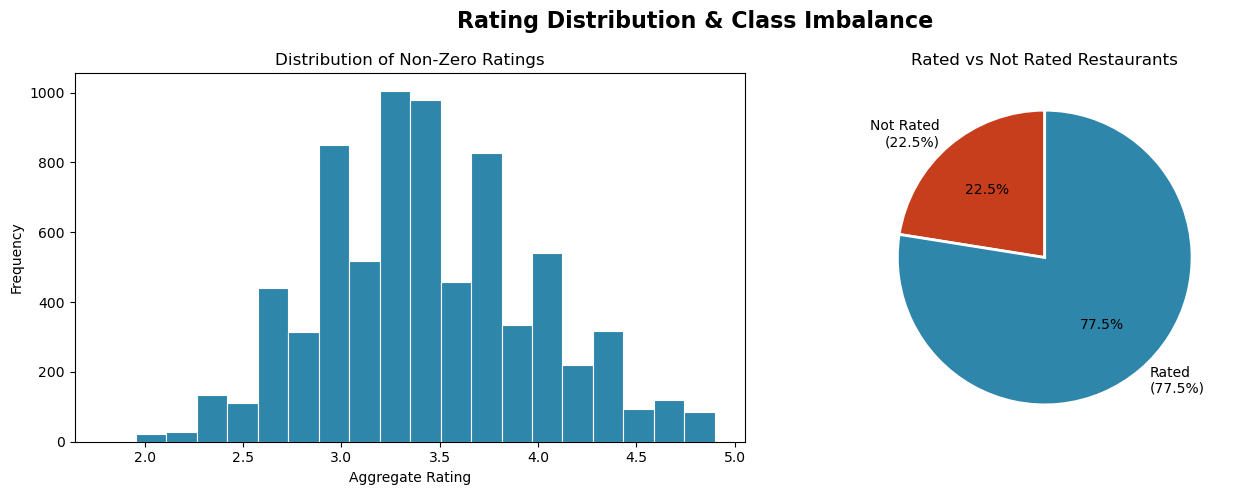

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    "Rating Distribution & Class Imbalance",
    fontsize=16,
    fontweight="bold"
)

# ---------------------------------
# 1️⃣ Histogram of Non-Zero Ratings
# ---------------------------------

axes[0].hist(
    df[df["Aggregate rating"] > 0]["Aggregate rating"],
    bins=20,
    color="#2E86AB",
    edgecolor="white",
    linewidth=0.8
)

axes[0].set_title("Distribution of Non-Zero Ratings")
axes[0].set_xlabel("Aggregate Rating")
axes[0].set_ylabel("Frequency")

# ---------------------------------
# 2️⃣ Pie Chart Rated vs Not Rated
# ---------------------------------

sizes = [zero_rated, rated]

labels = [
    f"Not Rated\n({zero_rated/df.shape[0]*100:.1f}%)",
    f"Rated\n({rated/df.shape[0]*100:.1f}%)"
]

colors = ["#C73E1D", "#2E86AB"]

axes[1].pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

axes[1].set_title("Rated vs Not Rated Restaurants")

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════
# LEVEL 1 │ TASK 2 – Descriptive Analysis
# ══════════════════════════════════════════════════

In [50]:
# Select Numerical Columns
numeric_columns = df.select_dtypes(include=['int', 'float'])

# Calculate basic statistical measures using .describe()
summary_stats = numeric_columns.describe()
print(summary_stats)

       Restaurant ID  Country Code    Longitude     Latitude  \
count   9.551000e+03   9551.000000  9551.000000  9551.000000   
mean    9.051128e+06     18.365616    64.126574    25.854381   
std     8.791521e+06     56.750546    41.467058    11.007935   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019625e+05      1.000000    77.081343    28.478713   
50%     6.004089e+06      1.000000    77.191964    28.570469   
75%     1.835229e+07      1.000000    77.282006    28.642758   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Has Table booking  Has Online delivery  \
count           9551.000000        9551.000000          9551.000000   
mean            1199.210763           0.121244             0.256622   
std            16121.183073           0.326428             0.436792   
min                0.000000           0.000000             0.000000   
25%              250.000000           0.000000             0.000000 

In [56]:
# Top 10 Cities
top_cities = df['City'].value_counts().head(10)
print(f"\n🏙  Top 10 Cities by Restaurant Count:")
print(top_cities.to_string())


🏙  Top 10 Cities by Restaurant Count:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21


In [54]:
# Top 10 Cuisines
cuisine_series = df['Cuisines'].str.split(', ').explode()
top_cuisines = cuisine_series.value_counts().head(10)
print(f"\n🍽  Top 10 Cuisines by Frequency:")
print(top_cuisines.to_string())


🍽  Top 10 Cuisines by Frequency:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636


In [58]:
# Country distribution
top_countries = df['Country Code'].value_counts().head(8)
print(f"\n🌍 Top Country Codes by Restaurant Count:")
print(top_countries.to_string())


🌍 Top Country Codes by Restaurant Count:
Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34


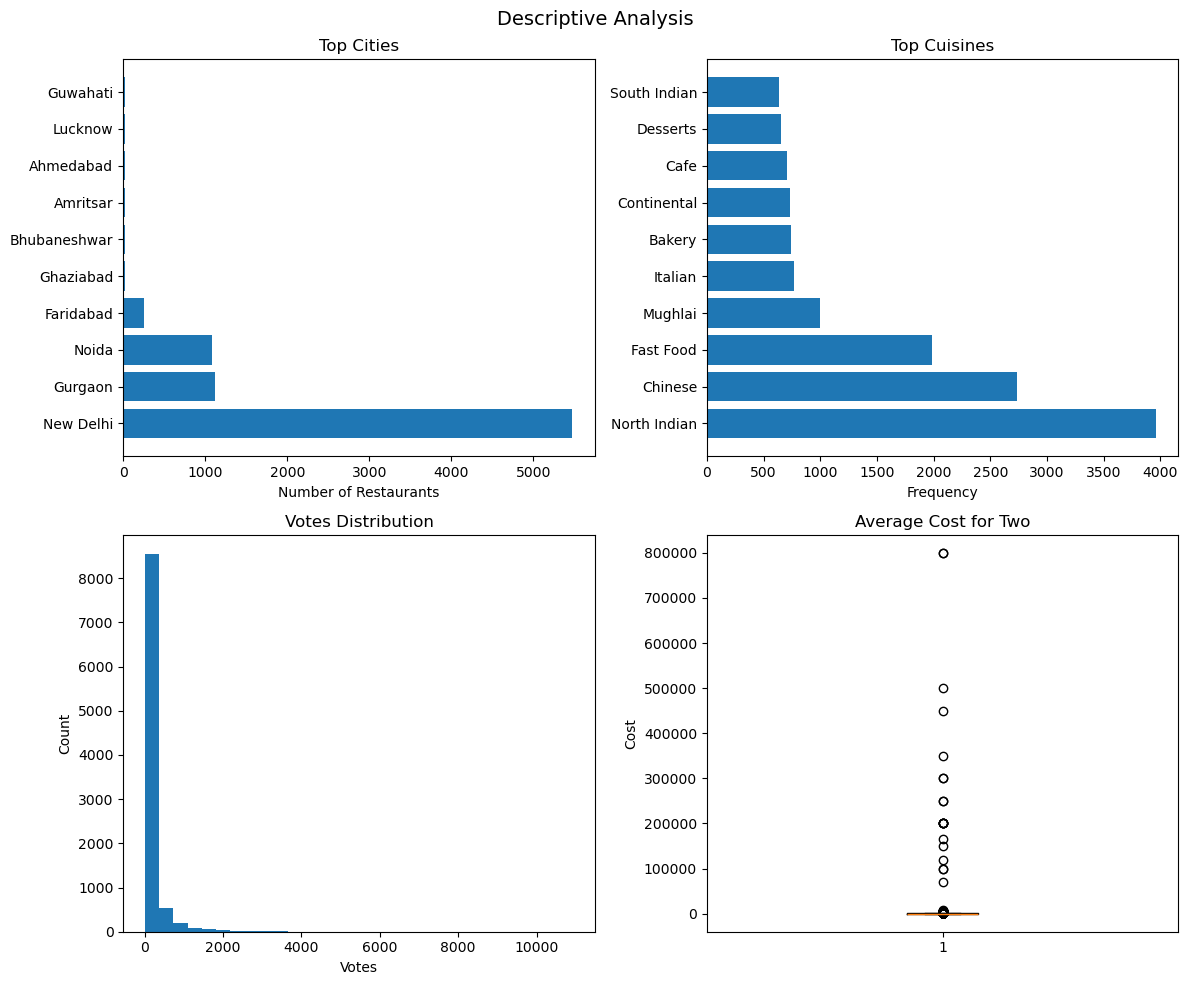

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

fig.suptitle("Descriptive Analysis", fontsize=14)

# 1️⃣ Top Cities
axes[0, 0].barh(top_cities.index, top_cities.values)
axes[0, 0].set_title("Top Cities")
axes[0, 0].set_xlabel("Number of Restaurants")

# 2️⃣ Top Cuisines
axes[0, 1].barh(top_cuisines.index, top_cuisines.values)
axes[0, 1].set_title("Top Cuisines")
axes[0, 1].set_xlabel("Frequency")

# 3️⃣ Votes Distribution
axes[1, 0].hist(df['Votes'], bins=30)
axes[1, 0].set_title("Votes Distribution")
axes[1, 0].set_xlabel("Votes")
axes[1, 0].set_ylabel("Count")

# 4️⃣ Average Cost for Two
axes[1, 1].boxplot(df['Average Cost for two'].dropna())
axes[1, 1].set_title("Average Cost for Two")
axes[1, 1].set_ylabel("Cost")

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════
# LEVEL 1 │ TASK 3 – Geospatial Analysis
# ══════════════════════════════════════════════════

In [84]:
# Filter valid latitude & longitude
geo_df = df[
    (df['Latitude'].between(-90, 90)) &
    (df['Longitude'].between(-180, 180)) &
    (df['Latitude'] != 0) &
    (df['Longitude'] != 0)]

print("Valid geo-tagged restaurants:", len(geo_df), "out of", len(df))

Valid geo-tagged restaurants: 9052 out of 9551


## Analyze the distribution of restaurants across different cities or countries

In [92]:
# City-wise restaurant counts
city_counts = df['City'].value_counts().reset_index()
city_counts.columns = ['City','Count']
print("\n🗺  Restaurant Count per City (Top 15):")
print(city_counts.head(15).to_string(index=False))


🗺  Restaurant Count per City (Top 15):
          City  Count
     New Delhi   5473
       Gurgaon   1118
         Noida   1080
     Faridabad    251
     Ghaziabad     25
  Bhubaneshwar     21
      Amritsar     21
     Ahmedabad     21
       Lucknow     21
      Guwahati     21
      Ludhiana     20
Rest of Hawaii     20
         Kochi     20
       Kolkata     20
     Pocatello     20


In [94]:
# Correlation: Location vs Rating
rated_geo = geo_df[geo_df['Aggregate rating']>0]
lat_corr  = rated_geo[['Latitude','Aggregate rating']].corr().iloc[0,1]
lon_corr  = rated_geo[['Longitude','Aggregate rating']].corr().iloc[0,1]
print(f"\n📍 Correlation – Latitude  vs Rating : {lat_corr:.4f}")
print(f"📍 Correlation – Longitude vs Rating : {lon_corr:.4f}")
print("   → Weak correlation indicates location alone doesn't determine rating.")



📍 Correlation – Latitude  vs Rating : -0.1893
📍 Correlation – Longitude vs Rating : -0.2991
   → Weak correlation indicates location alone doesn't determine rating.


In [100]:
!pip install geopandas

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   -- ------------------------------------- 1.3/22.9 MB 5.2 MB/s eta 0:00:05
   ----- ---------------------------------- 2.9/22.9 MB 5.8 MB/s eta 0:00:04
   ------- -------------------------------- 4.5/22.9 MB 6.1 MB/s eta 0:00:04
   ---------- ----------------------------- 6.0/22.9 MB 6.4 MB/s eta 0:00:03
   ------------- -------------------------- 7.6/22.9 MB 6.0 MB/s eta 0:00:03
   --------------- ------------------------ 8.9/22.9 MB 5.7 MB/s eta 0:00:03
   ------------------ --------------------- 10.5/22.9 MB 5.7 MB/s eta 0:00:03
   ------------------- -------------------- 11.3/22.9 MB 5.3 MB/s eta 0:00:03
   --------------------- ------------------ 12.1/22.9 MB 5.1 MB/s eta 0:00:03
   --------------------- ------------------ 12.6/22.9 MB 4.7 MB/s eta 0:00:03
   ---------------------- ----------------- 13.1/22.9 MB 4.6 MB/s eta 0:00:03
   ------------------------ --------------- 14.2/22.9 MB 4.4 MB/s eta 0:00:02


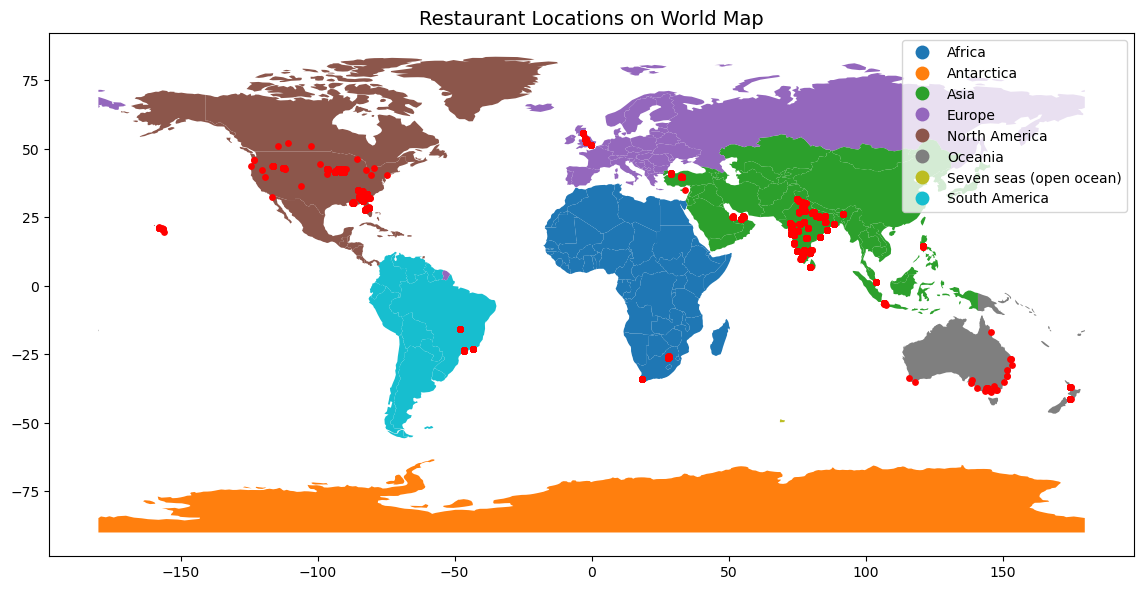

In [112]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Filter valid coordinates
geo_df = df[
    df['Latitude'].between(-90, 90) &
    df['Longitude'].between(-180, 180) &
    (df['Latitude'] != 0) &
    (df['Longitude'] != 0)
]

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(geo_df,geometry=gpd.points_from_xy(geo_df['Longitude'], geo_df['Latitude']))

# Load world dataset
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# Use correct column name here
continent_column = "CONTINENT" if "CONTINENT" in world.columns else "continent"

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

world.plot( column=continent_column,categorical=True,legend=True,ax=ax)
gdf.plot(ax=ax,color="red",markersize=15)

plt.title("Restaurant Locations on World Map", fontsize=14)
plt.show()

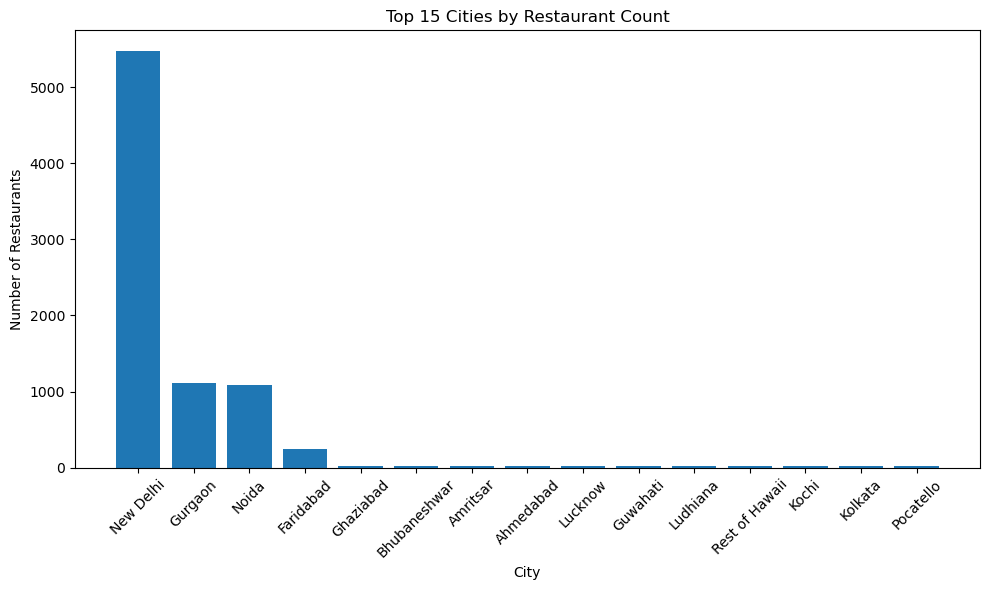

In [114]:
# Get top 15 cities
top15_cities = city_counts.head(15)

plt.figure(figsize=(10, 6))

plt.bar(top15_cities['City'], top15_cities['Count'])

plt.xticks(rotation=45)
plt.title("Top 15 Cities by Restaurant Count")
plt.ylabel("Number of Restaurants")
plt.xlabel("City")

plt.tight_layout()
plt.show()

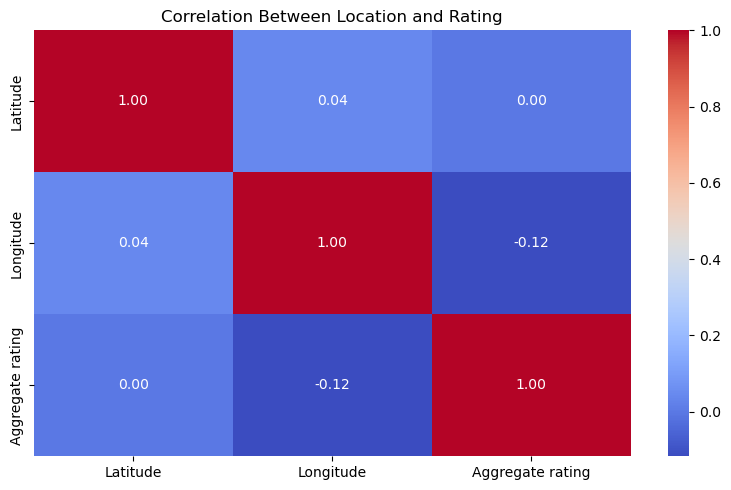

In [118]:
# Remove missing values
corr_data = df[['Latitude', 'Longitude', 'Aggregate rating']].dropna()

# Calculate correlation
correlation_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Between Location and Rating")
plt.tight_layout()
plt.show()